# 02 — Label Extraction

Extracts vulnerability labels from each train project's audit artefacts
(PDFs, bot-report.md, slither reports) and maps them to the taxonomy in
`dataset/Tag Definitions.md`.

**Outputs:** `dataset/train_labels.csv`

```
project_id | severity | tag | subtags | description
```

In [29]:
%pip install pdfplumber pandas matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
import sys
import importlib
from pathlib import Path

ROOT = Path().resolve().parent   # project root when notebook is in notebooks/
sys.path.insert(0, str(ROOT / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import label_extractor
importlib.reload(label_extractor)

from taxonomy import TAGS, SUBTAGS
from label_extractor import (
    TRAIN_DIR,
    extract_audit_text,
    split_findings,
    match_taxonomy,
    build_labels,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

print(f'Taxonomy: {len(TAGS)} tags, {len(SUBTAGS)} subtags')
print(f'Train projects: {sum(1 for p in TRAIN_DIR.iterdir() if p.is_dir())}')

Taxonomy: 38 tags, 68 subtags
Train projects: 54


---
## 1. Inspect a single project
Verify that text extraction and finding splitting work before running the full build.

In [ ]:
# Pick any train project — change the hash to explore others
SAMPLE = TRAIN_DIR / '289d8258d7b3'

text = extract_audit_text(SAMPLE)
findings = split_findings(text)

print(f'Project  : {SAMPLE.name}')
print(f'Text len : {len(text):,} chars')
print(f'Findings : {len(findings)}')
print()
from collections import Counter
print('Severity distribution:', dict(Counter(f['severity'] for f in findings)))
print()
print('--- First finding block ---')
f0 = findings[0]
print(f"  severity : {f0['severity']}")
print(f"  title    : {f0['title'][:80]}")
print(f"  text     : {f0['text'][:400]}")

In [ ]:
# Match taxonomy on the first few findings
for i, f in enumerate(findings[:5]):
    tags, subtags = match_taxonomy(f['title'] + ' ' + f['text'])
    if tags:
        print(f"Finding {i} [{f['severity']}]: {f['title'][:60]}")
        print(f'  tags   : {sorted(tags)}')
        print(f'  subtags: {sorted(subtags)[:6]}')

---
## 2. Build labels for all train projects

> **Note:** Projects with only PDF audits require `pdfplumber`:
> ```
> pip install pdfplumber
> ```
> Projects with only PDFs and no pdfplumber will be skipped with a warning.

In [ ]:
df = build_labels(TRAIN_DIR)

print(f'Rows         : {len(df)}')
print(f'Projects     : {df.project_id.nunique()}')
print(f'Unique tags  : {df.tag.nunique()}')
print()
df.head(10)

[info] 19000d572f72: no audit text found
[info] 29aba850d512: no audit text found
[info] 2cceea6fb3e4: no audit text found
[info] 33f83c1b20b8: no audit text found
[info] 347d893744f1: no audit text found
[info] 37dd0c2e7de6: no audit text found
[info] 4bea68ae8bc5: no audit text found
[info] 4dd1b2af57b2: no audit text found
[info] 529b81f6eb01: no audit text found
[info] 668a8ea1ed7c: no audit text found
[info] 6a503b3dea2b: no audit text found
[info] 727004c1c07c: no audit text found
[info] 8ce9aae8427c: no audit text found
[info] 9007dfde367e: no audit text found
[info] ac5c6d4a2ace: no audit text found
[info] b30036fd8ad6: no audit text found
[info] bc50c508bb4d: no audit text found
[info] c192cb02636e: no audit text found
[info] c9e8bb39a8ae: no audit text found
[info] d52ee365a168: no audit text found
[info] d5aa11e316e7: no audit text found
[info] edf1b6dd23d6: no audit text found
[info] f3d2dbfd99ea: no audit text found
Rows         : 269
Projects     : 28
Unique tags  : 36



,project_id,tag,subtags
0,1150ac69e096,Gnosis safe,[]
1,1150ac69e096,call / delegatecall,[]
2,1150ac69e096,EIP712,[Nonce]
3,1150ac69e096,Access Control,[Arbitrary Add/Remove/Set/Call]
4,1150ac69e096,DoS,"[Arbitrary Add/Remove/Set/Call, Hardcoded Para..."
5,1150ac69e096,Slippage,[Hardcoded Parameter]
6,1150ac69e096,Solidity Version,[]
7,1150ac69e096,ERC721,[]
8,1150ac69e096,Arithmetic,"[Block Time / Block Number, Hardcoded Parameter]"
9,1150ac69e096,Uniswap,"[Hardcoded Parameter, slot0]"


---
## 3. Coverage — which projects produced labels?

In [ ]:
all_projects = {p.name for p in TRAIN_DIR.iterdir() if p.is_dir() and not p.name.startswith('__')}
labelled     = set(df.project_id.unique())
unlabelled   = all_projects - labelled

print(f'Labelled   : {len(labelled)} / {len(all_projects)}')
print(f'Unlabelled : {len(unlabelled)}')
if unlabelled:
    print('  →', sorted(unlabelled))

Labelled   : 28 / 54
Unlabelled : 26
  → ['19000d572f72', '29aba850d512', '2cceea6fb3e4', '33f83c1b20b8', '347d893744f1', '37dd0c2e7de6', '4bea68ae8bc5', '4dd1b2af57b2', '50015cf871a0', '529b81f6eb01', '668a8ea1ed7c', '6a503b3dea2b', '727004c1c07c', '8b0abbf14c91', '8ce9aae8427c', '9007dfde367e', '966f040d9bc8', 'ac5c6d4a2ace', 'b30036fd8ad6', 'bc50c508bb4d', 'c192cb02636e', 'c9e8bb39a8ae', 'd52ee365a168', 'd5aa11e316e7', 'edf1b6dd23d6', 'f3d2dbfd99ea']


---
## 4. Tag frequency

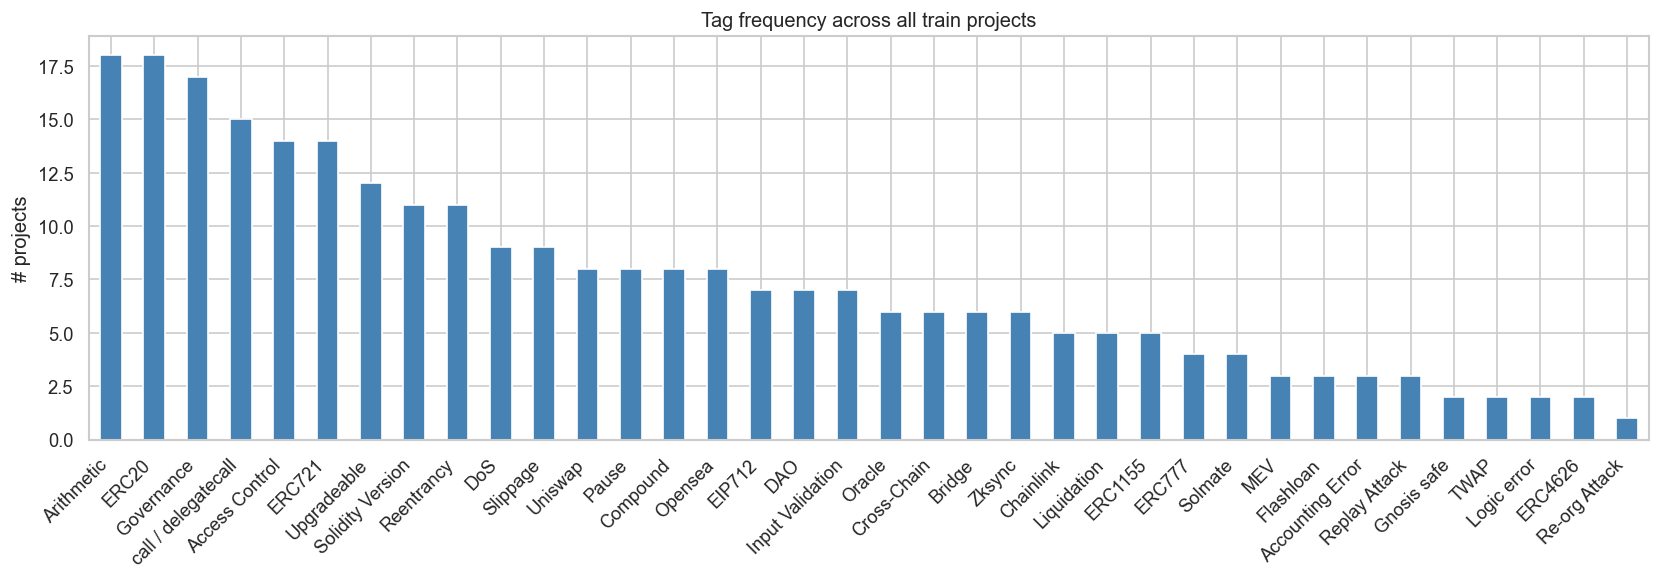

tag
Arithmetic             18
ERC20                  18
Governance             17
call / delegatecall    15
Access Control         14
ERC721                 14
Upgradeable            12
Solidity Version       11
Reentrancy             11
DoS                     9
Slippage                9
Uniswap                 8
Pause                   8
Compound                8
Opensea                 8
EIP712                  7
DAO                     7
Input Validation        7
Oracle                  6
Cross-Chain             6
Bridge                  6
Zksync                  6
Chainlink               5
Liquidation             5
ERC1155                 5
ERC777                  4
Solmate                 4
MEV                     3
Flashloan               3
Accounting Error        3
Replay Attack           3
Gnosis safe             2
TWAP                    2
Logic error             2
ERC4626                 2
Re-org Attack           1


In [ ]:
tag_counts = df.tag.value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
tag_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Tag frequency across all train projects')
ax.set_xlabel('')
ax.set_ylabel('# projects')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(tag_counts.to_string())

---
## 5. Tags per project (multi-label density)

count    28.000000
mean      9.607143
std       7.539227
min       1.000000
25%       3.000000
50%       7.000000
75%      15.250000
max      27.000000
Name: tag, dtype: float64


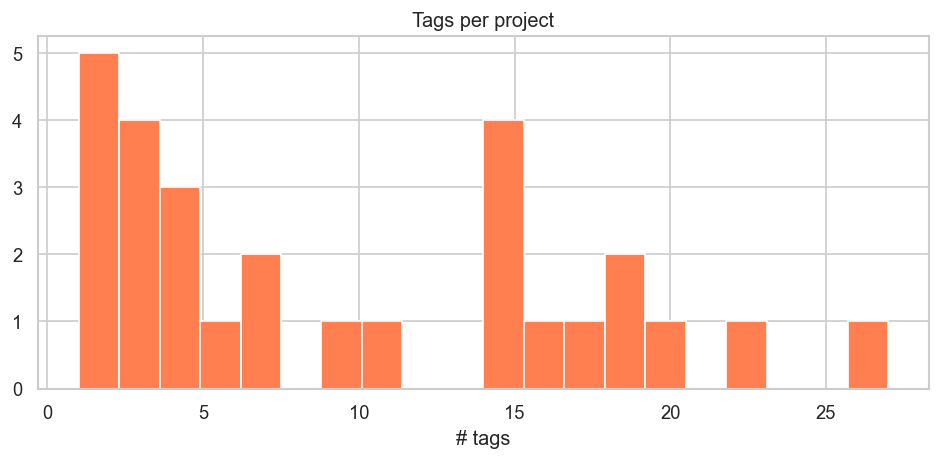

In [ ]:
tags_per_project = df.groupby('project_id')['tag'].count()
print(tags_per_project.describe())

fig, ax = plt.subplots(figsize=(8, 4))
tags_per_project.hist(bins=20, ax=ax, color='coral', edgecolor='white')
ax.set_title('Tags per project')
ax.set_xlabel('# tags')
plt.tight_layout()
plt.show()

---
## 6. Tag co-occurrence heatmap

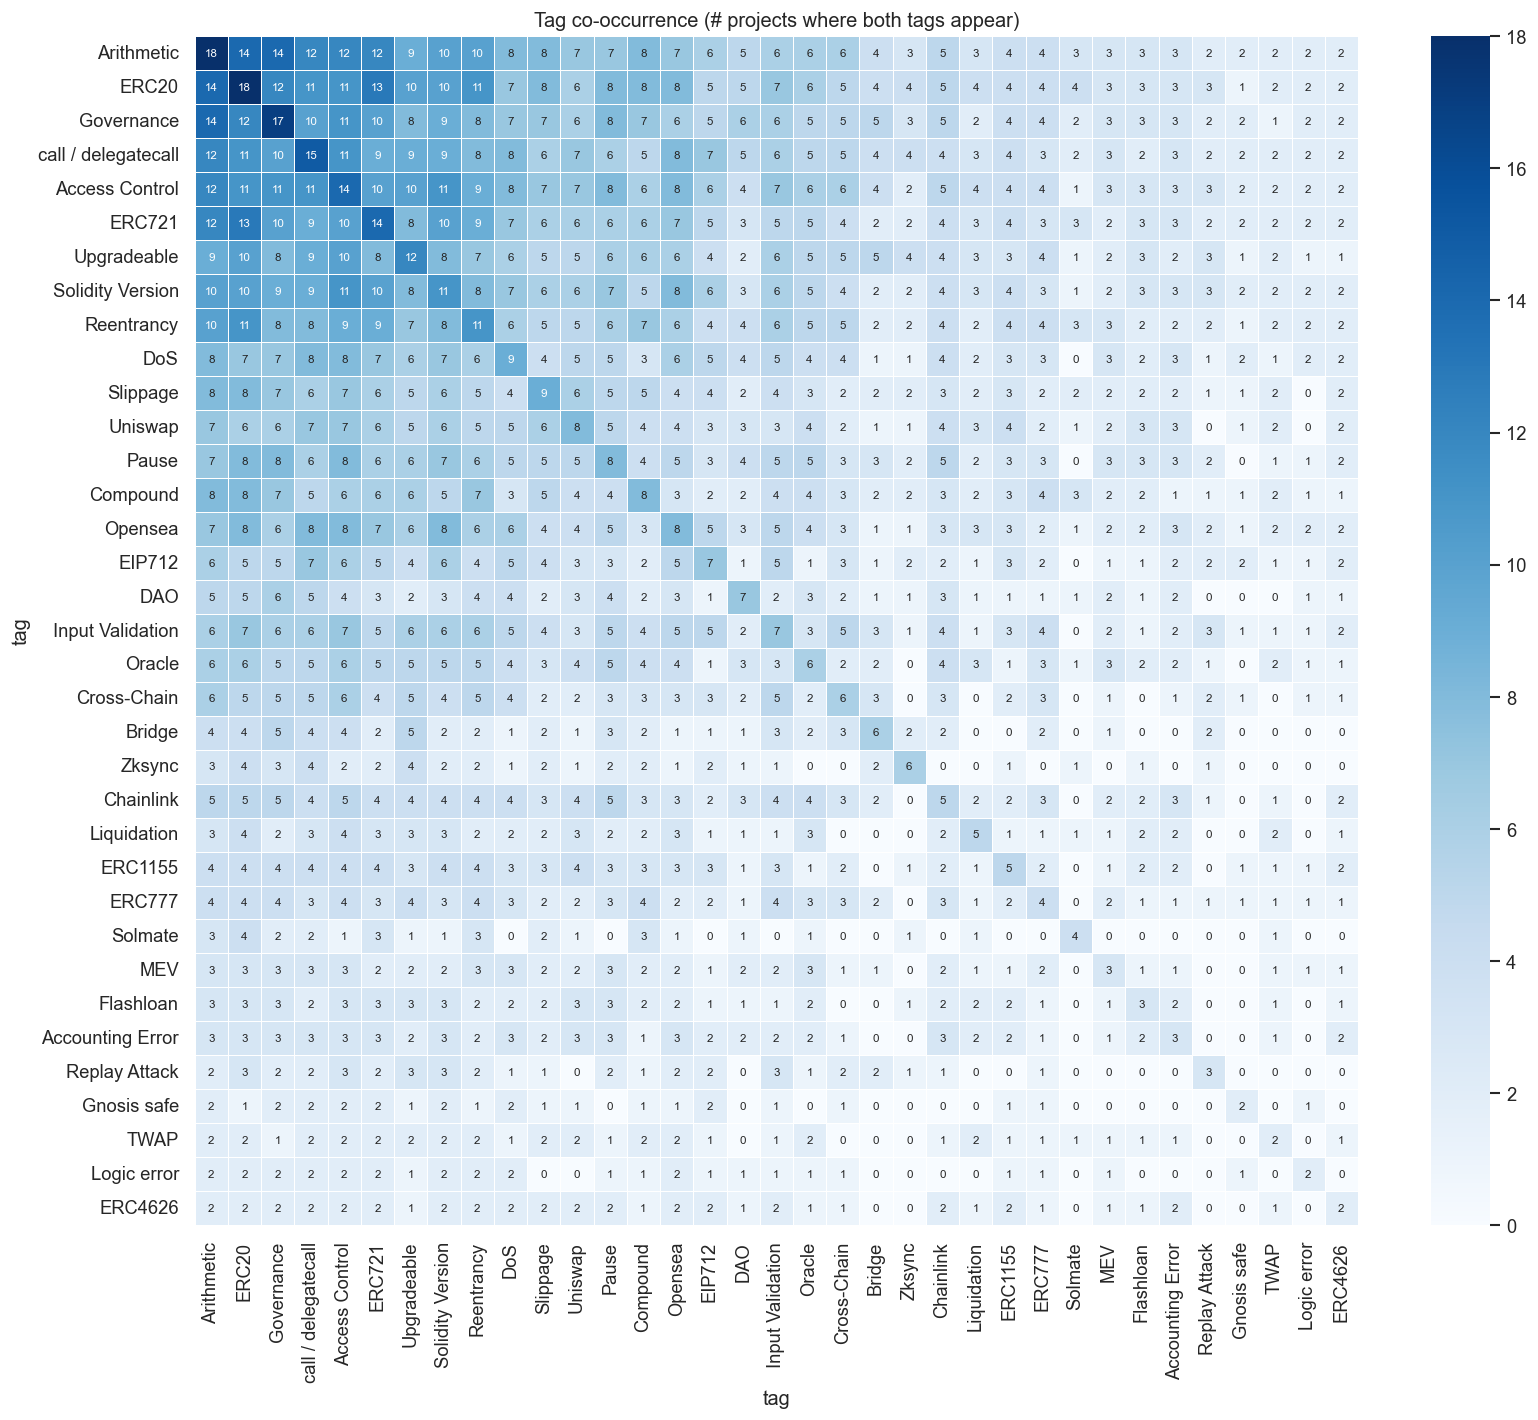

In [ ]:
# Build project × tag binary matrix
pivot = df.assign(val=1).pivot_table(
    index='project_id', columns='tag', values='val', aggfunc='max', fill_value=0
)

# Keep tags with >= 2 occurrences for readability
common_tags = tag_counts[tag_counts >= 2].index
pivot_filt  = pivot.reindex(columns=[c for c in common_tags if c in pivot.columns])

cooc = pivot_filt.T @ pivot_filt

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cooc, ax=ax, cmap='Blues', linewidths=0.3, annot=True, fmt='d', annot_kws={'size': 7})
ax.set_title('Tag co-occurrence (# projects where both tags appear)')
plt.tight_layout()
plt.show()

---
## 7. Review unlabelled projects
These either have no audit artefacts or are PDF-only (needs pdfplumber).

In [ ]:
from label_extractor import _collect_audit_files

for pid in sorted(unlabelled):
    proj = TRAIN_DIR / pid
    files = _collect_audit_files(proj)
    print(f'{pid}: {[f.name for f in files] or "NO AUDIT FILES"}')

19000d572f72: NO AUDIT FILES
29aba850d512: NO AUDIT FILES
2cceea6fb3e4: NO AUDIT FILES
33f83c1b20b8: NO AUDIT FILES
347d893744f1: NO AUDIT FILES
37dd0c2e7de6: NO AUDIT FILES
4bea68ae8bc5: NO AUDIT FILES
4dd1b2af57b2: NO AUDIT FILES
50015cf871a0: ['Code4rena - Archive-2021 - mellow-dec2 [915614197096800276].txt']
529b81f6eb01: NO AUDIT FILES
668a8ea1ed7c: NO AUDIT FILES
6a503b3dea2b: NO AUDIT FILES
727004c1c07c: NO AUDIT FILES
8b0abbf14c91: ['Code4rena - Archive-2021 - yetifinance-dec16 [920363113981820978].txt']
8ce9aae8427c: NO AUDIT FILES
9007dfde367e: NO AUDIT FILES
966f040d9bc8: ['Code4rena - Archive-2021 - covalent-oct19 [899660027286138911].txt']
ac5c6d4a2ace: NO AUDIT FILES
b30036fd8ad6: NO AUDIT FILES
bc50c508bb4d: NO AUDIT FILES
c192cb02636e: NO AUDIT FILES
c9e8bb39a8ae: NO AUDIT FILES
d52ee365a168: NO AUDIT FILES
d5aa11e316e7: NO AUDIT FILES
edf1b6dd23d6: NO AUDIT FILES
f3d2dbfd99ea: NO AUDIT FILES


---
## 8. Save `train_labels.csv`

In [ ]:
out = ROOT / 'dataset' / 'train_labels.csv'
df.to_csv(out, index=False)
print(f'Saved → {out}')
print(f'{len(df)} rows')

Saved → /Users/j6s1yn8z/LLM Identification of Smart Contract Vulnerabilities/dataset/train_labels.csv
269 rows
